# Neural Network Image-to-Sentence Mapping

## Set-up and Loading the data

In [ ]:
! pip install num2words bert_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.3 MB/s eta 0:00:00


In [ ]:
import os
from tqdm import tqdm
import random
import json
import re
import ast
from num2words import num2words
from transformers import BertTokenizerFast

from warnings import filterwarnings
filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import textwrap

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
import cv2

from collections import Counter

pd.options.display.max_rows = 500
pd.options.display.max_columns = 100

In [ ]:
BASE_DIR = "/content/drive/Othercomputers/My Laptop/Desktop/ITAITA_Project"
DATA_DIR = os.path.join(BASE_DIR, 'Data')
datasets = os.listdir(DATA_DIR)

datasets = [dataset for dataset in datasets if 'csv' not in dataset]


# Checking if paths exist
for dataset in datasets:
  print(dataset,os.path.exists(os.path.join(DATA_DIR, dataset)))

Numbers_Data True
TicTacToe_Data True
Shapes_Data True


In [ ]:
# print(torch.cuda.is_available())    # should print True
# print(torch.cuda.get_device_name()) # should print Tesla T4

## Reading the data
- Creating dataframe for each of the datasets
- Getting the file_name and the text.
- Making it easer to process the text.

In [ ]:
raw_data = {}
data_splits = ["train","test","val"]
for dataset in datasets:
  dataset_path = os.path.join(DATA_DIR, dataset)
  main_df = pd.DataFrame(columns=["file_name","file_path","text","split","dataset"])
  for split in data_splits:
    split_path = os.path.join(dataset_path, split)
    file_names = os.listdir(os.path.join(split_path,"images"))
    file_paths = [os.path.join(split_path,"images",file_name) for file_name in file_names]
    text = []
    for sample in tqdm(file_names):
      text_file_name = sample.split(".")[0]+".txt"
      with open(os.path.join(split_path,"text",text_file_name)) as f:
        text.append(f.read())
    split_type = len(text)*[split]
    dataset_type = len(text)*[dataset]
    df = pd.DataFrame({"file_name":file_names,"file_path":file_paths,"text":text,"split":split_type,"dataset":dataset_type})
    main_df = pd.concat([main_df,df],ignore_index=True)
  raw_data[dataset] = main_df
  print(f"Dataframe for {dataset} created")


file_names = []
file_paths = []
text = []
df = {}
main_df = {}

100%|██████████| 744/744 [00:02<00:00, 251.85it/s]


Dataframe for Numbers_Data created


100%|██████████| 750/750 [00:02<00:00, 273.65it/s]


Dataframe for TicTacToe_Data created


100%|██████████| 744/744 [00:02<00:00, 256.84it/s]

Dataframe for Shapes_Data created


In [ ]:
# Saving dataframe for future use.
for dataset in datasets:
  raw_data[dataset].to_csv(os.path.join(DATA_DIR,dataset+".csv"))

## Data Preprocessing

### Preprocessing Steps

| Step | Action | Example | Reason |
| :--- | :--- | :--- | :--- |
| **Player names** | Replace with `PLAYER_X` and `PLAYER_O` | Liam is X $\rightarrow$ `PLAYER_X` | Names inflate vocabulary; cannot be learned from image. |
| **Semicolons** | Replace with full stop and space | `...corner; PLAYER_O...` $\rightarrow$ `...corner. PLAYER_O...` | Keeps structure without rare punctuation tokens. |
| **Size words** | Normalise to *large, medium, small* | `sizeable`, `big` $\rightarrow$ `large` | Reduces vocabulary; cleaner mapping. |
| **Casing** | Lowercase everything | `Also visible` $\rightarrow$ `also visible` | Avoids duplicate tokens for the same word. |
| **Hyphens** | Keep in position words | `top-left`, `bottom-right` | Preserves positional meaning as a single token. |
| **Filler phrases** | Keep as-is | `also visible`, `there is` | Removing them breaks grammatical correctness. |
| **Commas** | Keep as-is | `a big circle, with...` | Carry structural meaning. |
| **Quotes/Brackets** | Remove | `"a big circle"` $\rightarrow$ `a big circle` | No semantic value. |
| **Numbers** | Convert to words | `63` $\rightarrow$ `sixty three` | Model learns digit names, not opaque tokens. |



### Reading the CSV files


In [ ]:
raw_data = {}
for dataset in datasets:
  raw_data[dataset] = pd.read_csv(os.path.join(DATA_DIR,dataset+".csv"),index_col=0)

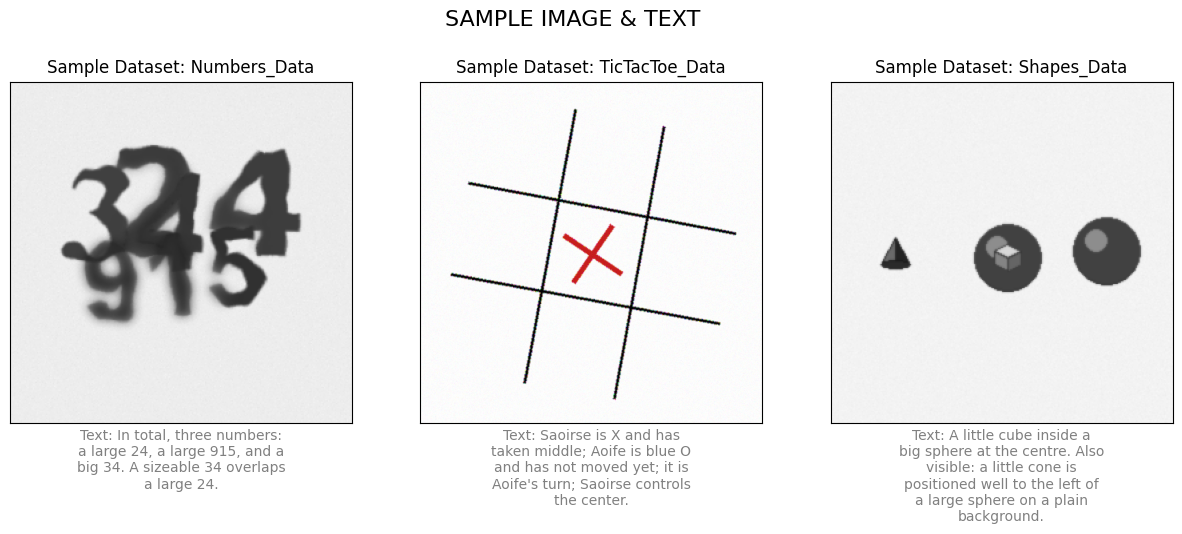

In [ ]:
plt.figure(figsize=(15, 5))
plt.suptitle('SAMPLE IMAGE & TEXT', fontsize=16)

for i in range(len(datasets)):
    plt.subplot(1, 3, i + 1)

    random_sample_index = random.randint(0, len(raw_data[datasets[i]]) - 1)
    img_path = raw_data[datasets[i]].iloc[random_sample_index, 1]

    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    raw_text = f"Text: {raw_data[datasets[i]].iloc[random_sample_index, 2]}"
    wrapped_text = "\n".join(textwrap.wrap(raw_text, width=30))

    plt.imshow(img_rgb)
    plt.title(f"Sample Dataset: {datasets[i]}", fontsize=12)
    plt.xlabel(wrapped_text, fontsize=10, color='gray')

    plt.xticks([])
    plt.yticks([])

plt.show()


### Player Names

In [ ]:
df = raw_data["TicTacToe_Data"].copy(deep=True)

In [ ]:
df.head()

,file_name,file_path,text,split,dataset
0,test_3550.png,/content/drive/Othercomputers/My Laptop/Deskto...,Liam is X and has taken up and left from cente...,train,TicTacToe_Data
1,test_3552.png,/content/drive/Othercomputers/My Laptop/Deskto...,"Aoife is red X and has taken middle, above the...",train,TicTacToe_Data
2,test_3551.png,/content/drive/Othercomputers/My Laptop/Deskto...,"Liam is X and has taken left of centre, top le...",train,TicTacToe_Data
3,test_3553.png,/content/drive/Othercomputers/My Laptop/Deskto...,"Liam is X and has taken middle row left, up an...",train,TicTacToe_Data
4,test_3555.png,/content/drive/Othercomputers/My Laptop/Deskto...,"Siobhán is X and has taken top left corner, do...",train,TicTacToe_Data


In [ ]:
df.shape

(5000, 5)

In [ ]:
# First word of ever sentence is a Name, So lets get all the names present in the data
names = set([text.split(' ')[0] for text in df['text']])
names

{'Aoife', 'Eoin', 'Liam', 'Niamh', 'Saoirse', 'Seán', 'Siobhán'}

In [ ]:
def replace_player_names(text):
    # 1. Identify who is X and who is O
    name_x_match = re.search(r'([A-Z][a-z]\w+) is\s*(?:red)?\s*X(?:\s+and)', text)
    name_o_match = re.search(r'([A-Z][a-z]\w+) is\s*(?:blue)?\s*O(?:\s+and)', text)
    # print(name_x_match)
    # print(name_o_match)
    if not name_x_match or not name_o_match:
        return text

    name_x = name_x_match.group(1)
    name_o = name_o_match.group(1)

    pattern_x = rf'\b{name_x}(\'s)?\b'
    pattern_o = rf'\b{name_o}(\'s)?\b'

    text = re.sub(rf'{name_x} is\s*(?:red)?\s*X(?:\s+and)', 'PLAYER_X', text)
    text = re.sub(rf'{name_o} is\s*(?:blue)?\s*O(?:\s+and)', 'PLAYER_O', text)


    text = re.sub(pattern_x, lambda m: "PLAYER_X" + (m.group(1) if m.group(1) else ""), text)
    text = re.sub(pattern_o, lambda m: "PLAYER_O" + (m.group(1) if m.group(1) else ""), text)

    text = text.replace("PLAYER_X is X", "PLAYER_X")
    text = text.replace("PLAYER_O is O", "PLAYER_O")

    text = re.sub(r'\bred\s+X\s+(?:and\s+)?(\w+)', r'PLAYER_X \1', text)
    text = re.sub(r'\bblue\s+O\s+(?:and\s+)?(\w+)', r'PLAYER_O \1', text)

    text = text.replace("  ", " ").strip()

    return text

In [ ]:
print("Original ------> " + df['text'].iloc[2])
replace_player_names(df['text'].iloc[2])

Original ------> Liam is X and has taken left of centre, top left corner, middle row right and below the center; Seán is O and has gone for bottom left corner, above the center and center; it is Seán's turn; Seán controls the center.



"PLAYER_X has taken left of centre, top left corner, middle row right and below the center; PLAYER_O has gone for bottom left corner, above the center and center; it is PLAYER_O's turn; PLAYER_O controls the center."

In [ ]:
testing_text = df['text'].apply(replace_player_names)

In [ ]:
testing_text

,text
0,"PLAYER_X has taken up and left from center, ri..."
1,"PLAYER_X has taken middle, above the center, d..."
2,"PLAYER_X has taken left of centre, top left co..."
3,"PLAYER_X has taken middle row left, up and lef..."
4,"PLAYER_X has taken top left corner, down and l..."
...,...
4995,"PLAYER_X has gone for above the center, up and..."
4996,"PLAYER_X has taken bottom right corner, top le..."
4997,"PLAYER_X has taken center, middle row right, b..."
4998,"PLAYER_X has taken up and right from center, u..."


In [ ]:
# checking if any of the names are still present
for i in names:
  for text in testing_text:
    if i in text:
      print(i)

In [ ]:
df['text'] = testing_text

In [ ]:
processed_data = {}
processed_data['TicTacToe_Data'] = df

### Semicolons

In [ ]:
df = processed_data["TicTacToe_Data"].copy(deep=True)

In [ ]:
df.head()

,file_name,file_path,text,split,dataset
0,test_3550.png,/content/drive/Othercomputers/My Laptop/Deskto...,"PLAYER_X has taken up and left from center, ri...",train,TicTacToe_Data
1,test_3552.png,/content/drive/Othercomputers/My Laptop/Deskto...,"PLAYER_X has taken middle, above the center, d...",train,TicTacToe_Data
2,test_3551.png,/content/drive/Othercomputers/My Laptop/Deskto...,"PLAYER_X has taken left of centre, top left co...",train,TicTacToe_Data
3,test_3553.png,/content/drive/Othercomputers/My Laptop/Deskto...,"PLAYER_X has taken middle row left, up and lef...",train,TicTacToe_Data
4,test_3555.png,/content/drive/Othercomputers/My Laptop/Deskto...,"PLAYER_X has taken top left corner, down and l...",train,TicTacToe_Data


In [ ]:
df['text'] = df['text'].apply(lambda x: x.replace(";","."))

In [ ]:
processed_data["TicTacToe_Data"] = df

### Lower Case, Removing Q&A and Normalising Size words

In [ ]:
master_data = pd.DataFrame()
for dataset in datasets:
  if dataset in processed_data:
    df = processed_data[dataset]
  else:
    df = raw_data[dataset]
  master_data = pd.concat([master_data,df],ignore_index=True)

In [ ]:
master_data.shape

(15000, 5)

In [ ]:
# Converting all the text to lower case.
master_data['text'] = master_data['text'].apply(lambda x: x.lower())
master_data['text'] = master_data['text'].apply(lambda x: x.strip())
master_data['text'] = master_data['text'].apply(lambda x: x.replace(";","."))

In [ ]:
def convert_question_to_sentence(text):
  test_text = text
  # print(text)
  # text = text.replace("also visible:","")
  question = re.search(r'(also visible:|where is the)(.+?\?)',text).group()
  # print(str(question))
  # print(question.group(2))
  object_ = re.search(r'(?:where is the) (.+?)\?',str(question)).group(1)
  # print(object_)
  text = text.replace(str(question),"")
  text = text.replace(" it is","the "+object_+" is")
  # print(text)
  return text


def normalise_size_words(text):
  text = text.replace("big","large")
  text = text.replace("sizeable","large")
  text = text.replace("little","small")
  text = text.replace("tiny","small")
  text = text.replace("medium-sized","medium")
  text = text.replace("mid-sized","medium")
  return text

In [ ]:
master_data['text'] = master_data['text'].apply(lambda x: convert_question_to_sentence(x) if '?' in x else x)
master_data['text'] = master_data['text'].apply(lambda x: normalise_size_words(x))

### Numbers-to-words

In [ ]:
def number_to_words(text):
    numbers = sorted(re.findall(r'\d+', text), key=len, reverse=True)
    for number in numbers:
        num_words = num2words(int(number))
        num_words = num_words.replace(",", "")
        num_words = num_words.replace("-", " ")
        text = re.sub(r'\b' + number + r'\b', num_words, text)
    return text

In [ ]:
master_data['text'] = master_data['text'].apply(lambda x: number_to_words(x))

In [ ]:
master_data.to_csv(os.path.join(DATA_DIR,"master_data.csv"))

## Tokeniser

### Special Tokens

| Token | Purpose |
| :--- | :--- |
| `<PAD>` | Pads all sentences in a batch to the same length. |
| `<START>` | Signals the decoder to begin generating. |
| `<END>` | Signals the decoder to stop generating. |
| `<UNK>` | Replaces any token not seen during training. |

### Sequence Settings
*   **Max token length:** 50 tokens (including `START` and `END`).
*   **Tokenisation:** Split on whitespace and punctuation.
*   **Vocabulary:** Built from all three training datasets combined.

### Checking data

In [ ]:
master_data = pd.read_csv("/content/drive/Othercomputers/My Laptop/Desktop/ITAITA_Project/Data/master_data.csv")

In [ ]:
master_data.shape

(15000, 6)

In [ ]:
master_data.head()

,Unnamed: 0,file_name,file_path,text,split,dataset
0,0,sample_003565.png,/content/drive/Othercomputers/My Laptop/Deskto...,"in total, three numbers: a large ninety one, a...",train,Numbers_Data
1,1,sample_003571.png,/content/drive/Othercomputers/My Laptop/Deskto...,four numbers are visible: a medium seven hundr...,train,Numbers_Data
2,2,sample_003570.png,/content/drive/Othercomputers/My Laptop/Deskto...,three numbers appear in the scene: a medium ei...,train,Numbers_Data
3,3,sample_003569.png,/content/drive/Othercomputers/My Laptop/Deskto...,"the scene contains a medium three, a large fou...",train,Numbers_Data
4,4,sample_003572.png,/content/drive/Othercomputers/My Laptop/Deskto...,"in total, four numbers: a small forty two, a s...",train,Numbers_Data


In [ ]:
master_data.drop(columns=["Unnamed: 0"],inplace=True)

In [ ]:
master_data[['dataset','split']].value_counts()

dataset         split
Numbers_Data    train    3512
Shapes_Data     train    3512
TicTacToe_Data  train    3500
                val       750
                test      750
Numbers_Data    test      744
                val       744
Shapes_Data     test      744
                val       744
Name: count, dtype: int64

In [ ]:
print(master_data.head())
print(master_data.columns)
print(master_data.shape)

           file_name                                          file_path  \
0  sample_003565.png  /content/drive/Othercomputers/My Laptop/Deskto...   
1  sample_003571.png  /content/drive/Othercomputers/My Laptop/Deskto...   
2  sample_003570.png  /content/drive/Othercomputers/My Laptop/Deskto...   
3  sample_003569.png  /content/drive/Othercomputers/My Laptop/Deskto...   
4  sample_003572.png  /content/drive/Othercomputers/My Laptop/Deskto...   

                                                text  split       dataset  
0  in total, three numbers: a large ninety one, a...  train  Numbers_Data  
1  four numbers are visible: a medium seven hundr...  train  Numbers_Data  
2  three numbers appear in the scene: a medium ei...  train  Numbers_Data  
3  the scene contains a medium three, a large fou...  train  Numbers_Data  
4  in total, four numbers: a small forty two, a s...  train  Numbers_Data  
Index(['file_name', 'file_path', 'text', 'split', 'dataset'], dtype='object')
(15000, 5)


In [ ]:
train_data = master_data[master_data['split'] == 'train'].copy(deep=True)
val_data   = master_data[master_data['split'] == 'val'].copy(deep=True)
test_data  = master_data[master_data['split'] == 'test'].copy(deep=True)

### Tokenisation

In [ ]:
def tokenise(text):
    tokens = re.findall(r'\b\w+(?:-\w+)*\b|[.,!?]', text)
    return tokens

In [ ]:
train_data['tokens'] = train_data['text'].apply(tokenise)
val_data['tokens']   = val_data['text'].apply(tokenise)
test_data['tokens']  = test_data['text'].apply(tokenise)

In [ ]:
train_data[train_data['text'].str.contains('-')]['text'].iloc[0]

'a small five thousand two hundred and fifty three, with five in orange, two in yellow, five in green and three in purple at the middle-left and a large orange nine at the middle-right appear in the scene.'

In [ ]:
sample = train_data[train_data['text'].str.contains('-')]['text'].iloc[0]
print(tokenise(sample))

['a', 'small', 'five', 'thousand', 'two', 'hundred', 'and', 'fifty', 'three', ',', 'with', 'five', 'in', 'orange', ',', 'two', 'in', 'yellow', ',', 'five', 'in', 'green', 'and', 'three', 'in', 'purple', 'at', 'the', 'middle-left', 'and', 'a', 'large', 'orange', 'nine', 'at', 'the', 'middle-right', 'appear', 'in', 'the', 'scene', '.']


### Building the vocabulary and simple Word-to-Index encoder.



In [ ]:
# Only from the training data
all_tokens = [token for tokens in train_data['tokens'] for token in tokens]

In [ ]:
token_counts = Counter(all_tokens)

In [ ]:
print(f"Total unique tokens: {len(token_counts)}")
print(token_counts.most_common(10))

Total unique tokens: 168
[('and', 22495), (',', 22452), ('.', 22419), ('a', 22200), ('in', 13202), ('the', 12563), ('has', 8627), ('small', 8309), ('large', 8280), ('center', 7200)]


In [ ]:
special_tokens = ['<PAD>', '<START>', '<END>', '<UNK>']
vocab = special_tokens + [token for token, count in token_counts.items()]
word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for idx, word in enumerate(vocab)}

In [ ]:
print(f"Vocabulary size: {len(word2idx)}")
print(f"PAD index: {word2idx['<PAD>']}")
print(f"START index: {word2idx['<START>']}")
print(f"END index: {word2idx['<END>']}")
print(f"UNK index: {word2idx['<UNK>']}")

# test a real word
print(f"'the' index: {word2idx['the']}")
print(f"idx2word[0]: {idx2word[0]}")

Vocabulary size: 172
PAD index: 0
START index: 1
END index: 2
UNK index: 3
'the' index: 31
idx2word[0]: <PAD>


In [ ]:
with open('/content/drive/Othercomputers/My Laptop/Desktop/ITAITA_Project/Config/word2idx.json', 'w') as f:
    json.dump(word2idx, f)
print(f"Saved. Size: {len(word2idx)}")

with open('/content/drive/Othercomputers/My Laptop/Desktop/ITAITA_Project/Config/idx2word.json', 'w') as f:
    json.dump(idx2word, f)
print(f"Saved. Size: {len(idx2word)}")


Saved. Size: 172
Saved. Size: 172


### Testing Word-to-Index Encoder

In [ ]:
def encode(tokens):
    # add start and end, convert to integers
    tokens = ['<START>']+tokens+['<END>']
    tokens = [word2idx.get(token, word2idx['<UNK>']) for token in tokens]
    return tokens

In [ ]:
sample_tokens = train_data['tokens'].iloc[0]
encoded = encode(sample_tokens)
print(encoded)
print(f"Length: {len(encoded)}")

# verify start and end
print(f"First token: {encoded[0]}")   # should be 1 (<START>)
print(f"Last token: {encoded[-1]}")   # should be 2 (<END>)

[1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 6, 9, 13, 14, 15, 16, 17, 6, 16, 9, 13, 18, 19, 20, 15, 16, 21, 22, 23, 9, 10, 11, 12, 24, 9, 13, 14, 15, 16, 17, 23, 2]
Length: 42
First token: 1
Last token: 2


In [ ]:
train_data['simple_encoding'] = train_data['tokens'].apply(encode)
val_data['simple_encoding']   = val_data['tokens'].apply(encode)
test_data['simple_encoding']  = test_data['tokens'].apply(encode)

### Padding to 150 tokens

In [ ]:
def pad(encoded, max_length=150):
    # pad or truncate to max_length
    if len(encoded) > max_length:
        encoded = encoded[:max_length]
    else:
        encoded = encoded + [word2idx['<PAD>']] * (max_length - len(encoded))
    return encoded

In [ ]:
# test padding (short sequence)
short = encode(['player_x', 'has', 'won', '.'])
padded = pad(short)
print(f"Length: {len(padded)}")
print(f"Last few tokens: {padded[-5:]}")  # should end with 0s

# test truncation (long sequence)
long = encode(['word'] * 200)
truncated = pad(long)
print(f"Truncated length: {len(truncated)}")  # should be 150

Length: 150
Last few tokens: [0, 0, 0, 0, 0]
Truncated length: 150


In [ ]:
train_data['padded'] = train_data['simple_encoding'].apply(pad)
val_data['padded']   = val_data['simple_encoding'].apply(pad)
test_data['padded']  = test_data['simple_encoding'].apply(pad)

In [ ]:
# every sequence should be exactly 150
assert all(len(x) == 150 for x in train_data['padded'])
assert all(len(x) == 150 for x in val_data['padded'])
assert all(len(x) == 150 for x in test_data['padded'])
print("All sequences are length 150 ✅")

All sequences are length 150 ✅


### Checking Coverage on Val and Test set

In [ ]:
def count_unknowns(encoded_series):
    unk_idx = word2idx['<UNK>']
    total_tokens = sum(len(seq) for seq in encoded_series)
    unk_count = sum(seq.count(unk_idx) for seq in encoded_series)
    return unk_count / total_tokens * 100

print(f"Val UNK%:  {count_unknowns(val_data['simple_encoding']):.2f}%")
print(f"Test UNK%: {count_unknowns(test_data['simple_encoding']):.2f}%")

Val UNK%:  0.00%
Test UNK%: 0.00%


### Pre-trained tokeniser

In [ ]:
train_data.head()

NameError: name 'train_data' is not defined

In [ ]:
bert_tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
def bert_encode_batch(texts):
    encoded = bert_tokenizer(
        texts.tolist(),
        add_special_tokens=True,
        truncation=True,
        max_length=150,
        padding="max_length",
        return_attention_mask=True,
        return_token_type_ids=False
    )
    return encoded["input_ids"], encoded["attention_mask"]

for df in [train_data, val_data, test_data]:
    ids, masks = bert_encode_batch(df["text"])
    df["bert_input_ids"] = ids
    df["bert_attention_mask"] = masks

NameError: name 'train_data' is not defined

In [ ]:
train_data.head()

NameError: name 'train_data' is not defined

In [ ]:
# master_encoded_data = pd.concat([train_data,val_data,test_data],ignore_index=True)
# master_encoded_data.head()
# master_encoded_data.to_csv(os.path.join(DATA_DIR,"master_encoded_data.csv"))

## Data Loader

In [ ]:
df = pd.read_csv(os.path.join(DATA_DIR,"master_encoded_data.csv"))
df= df.drop(columns=["Unnamed: 0"])

cols_to_parse = ['padded', 'simple_encoding', 'bert_input_ids', 'bert_attention_mask']

for col in cols_to_parse:
    if col in df.columns:
        df[col] = df[col].apply(ast.literal_eval)

print("Columns parsed successfully")
df.head()

Columns parsed successfully


,file_name,file_path,text,split,dataset,tokens,simple_encoding,padded,bert_input_ids,bert_attention_mask
0,sample_003565.png,/content/drive/Othercomputers/My Laptop/Deskto...,"in total, three numbers: a large ninety one, a...",train,Numbers_Data,"['in', 'total', ',', 'three', 'numbers', 'a', ...","[1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 6, 9, 13, 14...","[1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 6, 9, 13, 14...","[101, 1999, 2561, 1010, 2093, 3616, 1024, 1037...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,sample_003571.png,/content/drive/Othercomputers/My Laptop/Deskto...,four numbers are visible: a medium seven hundr...,train,Numbers_Data,"['four', 'numbers', 'are', 'visible', 'a', 'me...","[1, 17, 8, 25, 26, 9, 13, 27, 15, 16, 20, 6, 9...","[1, 17, 8, 25, 26, 9, 13, 27, 15, 16, 20, 6, 9...","[101, 2176, 3616, 2024, 5710, 1024, 1037, 5396...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
2,sample_003570.png,/content/drive/Othercomputers/My Laptop/Deskto...,three numbers appear in the scene: a medium ei...,train,Numbers_Data,"['three', 'numbers', 'appear', 'in', 'the', 's...","[1, 7, 8, 30, 4, 31, 32, 9, 13, 18, 6, 9, 10, ...","[1, 7, 8, 30, 4, 31, 32, 9, 13, 18, 6, 9, 10, ...","[101, 2093, 3616, 3711, 1999, 1996, 3496, 1024...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,sample_003569.png,/content/drive/Othercomputers/My Laptop/Deskto...,"the scene contains a medium three, a large fou...",train,Numbers_Data,"['the', 'scene', 'contains', 'a', 'medium', 't...","[1, 31, 32, 35, 9, 13, 7, 6, 9, 10, 36, 6, 16,...","[1, 31, 32, 35, 9, 13, 7, 6, 9, 10, 36, 6, 16,...","[101, 1996, 3496, 3397, 1037, 5396, 2093, 1010...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,sample_003572.png,/content/drive/Othercomputers/My Laptop/Deskto...,"in total, four numbers: a small forty two, a s...",train,Numbers_Data,"['in', 'total', ',', 'four', 'numbers', 'a', '...","[1, 4, 5, 6, 17, 8, 9, 28, 37, 20, 6, 9, 28, 2...","[1, 4, 5, 6, 17, 8, 9, 28, 37, 20, 6, 9, 28, 2...","[101, 1999, 2561, 1010, 2176, 3616, 1024, 1037...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


In [ ]:
df['dataset'].unique()

array(['Numbers_Data', 'TicTacToe_Data', 'Shapes_Data'], dtype=object)

In [ ]:
train_data = df[df['split'] == 'train'].reset_index(drop=True)
val_data   = df[df['split'] == 'val'].reset_index(drop=True)
test_data  = df[df['split'] == 'test'].reset_index(drop=True)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

Train: 10524 | Val: 2238 | Test: 2238


In [ ]:
class ImageCaptionDataset(Dataset):
    def __init__(self, dataframe,encoding="simple"):
        self.data = dataframe
        self.transform = transforms.Compose([
            transforms.Resize((128, 128)),
            transforms.ToTensor(),           # converts to tensor and scales 0-255 to 0-1
        ])
        assert encoding in ("simple", "bert"), f"Unknown encoding: {encoding}"
        self.encoding = encoding

    def __len__(self):
        # return number of samples
        return len(self.data)
        ...

    def __getitem__(self, idx):
        # 1. get file path and load image
        # 2. convert L to RGB if needed
        # 3. apply transforms
        # 4. get the padded encoded sequence
        # 5. return image tensor and sequence tensor
        row = self.data.iloc[idx]

        image = Image.open(row['file_path']).convert('RGB')
        image_tensor = self.transform(image)

        if self.encoding == "simple":
            sequence_tensor = torch.tensor(row['padded'], dtype=torch.long)
            return image_tensor, sequence_tensor

        else:
            input_ids = torch.tensor(row['bert_input_ids'], dtype=torch.long)
            attention_mask = torch.tensor(row['bert_attention_mask'], dtype=torch.long)
            return image_tensor, input_ids, attention_mask

In [ ]:
train_dataset_simple = ImageCaptionDataset(train_data)
val_dataset_simple   = ImageCaptionDataset(val_data)
test_dataset_simple  = ImageCaptionDataset(test_data)

train_dataset_bert = ImageCaptionDataset(train_data,encoding="bert")
val_dataset_bert   = ImageCaptionDataset(val_data,encoding="bert")
test_dataset_bert  = ImageCaptionDataset(test_data,encoding="bert")


train_loader_simple = DataLoader(train_dataset_simple, batch_size=64, shuffle=True)
val_loader_simple   = DataLoader(val_dataset_simple,   batch_size=64, shuffle=False)
test_loader_simple = DataLoader(test_dataset_simple,  batch_size=64, shuffle=False)

train_loader_bert = DataLoader(train_dataset_bert, batch_size=64, shuffle=True)
val_loader_bert   = DataLoader(val_dataset_bert,   batch_size=64, shuffle=False)
test_loader_bert  = DataLoader(test_dataset_bert,  batch_size=64, shuffle=False)

In [ ]:
images, sequences = next(iter(train_loader_simple))
print(f"Image batch shape:    {images.shape}")
print(f"Sequence batch shape: {sequences.shape}")

image_tensor, input_ids, attention_mask = next(iter(train_loader_bert))
print(f"Image batch shape:    {image_tensor.shape}")
print(f"Input IDs shape:      {input_ids.shape}")
print(f"Attention mask shape: {attention_mask.shape}")

Image batch shape:    torch.Size([64, 3, 128, 128])
Sequence batch shape: torch.Size([64, 150])
Image batch shape:    torch.Size([64, 3, 128, 128])
Input IDs shape:      torch.Size([64, 150])
Attention mask shape: torch.Size([64, 150])


## Transformer Decoder

transformer_decoder_architecture.svg

In [ ]:
from transformers import BertModel

class TransformerDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, max_length=150, num_heads=8,
                 N_layers=3, ff_dim=512, dropout=0.1, use_bert=False):
        super().__init__()
        self.use_bert = use_bert

        if use_bert:
            bert = BertModel.from_pretrained("bert-base-uncased")
            self.bert_embeddings = bert.embeddings  # token + positional embeddings only
            self.bert_proj = nn.Linear(768, embed_dim)  # BERT is 768-dim, project down
        else:
            self.embedding = nn.Embedding(vocab_size, embed_dim)
            self.pos_embedding = nn.Embedding(max_length, embed_dim)

        self.embed_dim = embed_dim
        decoder_layer = nn.TransformerDecoderLayer(embed_dim, num_heads, ff_dim, dropout, batch_first=True)
        self.transformer = nn.TransformerDecoder(decoder_layer, num_layers=N_layers)
        self.fc_out = nn.Linear(embed_dim, vocab_size)

    def forward(self, tgt, memory, attention_mask=None):
        seq_len = tgt.shape[1]

        if self.use_bert:
            x = self.bert_embeddings(input_ids=tgt)   # [batch, seq_len, 768]
            x = self.bert_proj(x)                      # [batch, seq_len, embed_dim]
            # PyTorch padding mask: True = ignore this position (opposite of BERT's convention)
            tgt_key_padding_mask = (attention_mask == 0) if attention_mask is not None else None
        else:
            positions = torch.arange(seq_len, device=tgt.device)
            x = self.embedding(tgt) + self.pos_embedding(positions)
            tgt_key_padding_mask = None

        mask = nn.Transformer.generate_square_subsequent_mask(seq_len, device=tgt.device)
        x = self.transformer(x, memory, tgt_mask=mask, tgt_key_padding_mask=tgt_key_padding_mask)
        x = self.fc_out(x)
        return x

In [ ]:
# create decoder
decoder = TransformerDecoder(vocab_size=bert_tokenizer.vocab_size,use_bert=True)

# dummy inputs
batch_size = 2
seq_len    = 10
num_patches = 64  # 8x8 CNN feature map flattened
embed_dim  = 256

tgt    = torch.randint(0, 172, (batch_size, seq_len))         # fake token sequences
memory = torch.randn(batch_size, num_patches, embed_dim)      # fake CNN features

# forward pass
output = decoder(tgt, memory)
print(f"Input shape:  {tgt.shape}")
print(f"Memory shape: {memory.shape}")
print(f"Output shape: {output.shape}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Input shape:  torch.Size([2, 10])
Memory shape: torch.Size([2, 64, 256])
Output shape: torch.Size([2, 10, 30522])


In [ ]:
print(bert_tokenizer.pad_token_id)      # should be 0
print(bert_tokenizer.pad_token)         # should be '[PAD]'
print(bert_tokenizer.cls_token_id)      # [CLS] — your effective <START>, should be 101
print(bert_tokenizer.sep_token_id)      # [SEP] — your effective <END>, should be 102

0
[PAD]
101
102


## Approach A — Shallow CNN

In [ ]:
class ShallowCNN(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=64, out_channels=256, kernel_size=3, padding=1)
        self.proj = nn.Conv2d(256, embed_dim, kernel_size=1)


    def forward(self, x):
        # pass through conv layers
        conv1 = F.max_pool2d(F.relu(self.conv1(x)),2)
        conv2 = F.max_pool2d(F.relu(self.conv2(conv1)),2)
        conv2 = self.proj(conv2)
        # flatten spatial dims
        x = conv2.flatten(2)
        # permute to [batch, num_patches, embed_dim]
        x = x.permute(0, 2, 1)
        return x

In [ ]:
cnn = ShallowCNN()
x = torch.randn(2, 3, 128, 128)
out = cnn(x)
print(out.shape)

torch.Size([2, 1024, 256])


In [ ]:
# create both models
cnn     = ShallowCNN()
decoder = TransformerDecoder(vocab_size=172)

# dummy inputs
images = torch.randn(2, 3, 128, 128)
tokens = torch.randint(0, 172, (2, 10))

# forward pass through both
memory = cnn(images)
output = decoder(tokens, memory)

print(f"CNN output shape:     {memory.shape}")
print(f"Decoder output shape: {output.shape}")

CNN output shape:     torch.Size([2, 1024, 256])
Decoder output shape: torch.Size([2, 10, 172])


## Approach B — Deep CNN

In [ ]:
class DeepCNN(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        # 5 conv layers + projection
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1)
        self.proj = nn.Conv2d(256, embed_dim, kernel_size=1)
    def forward(self, x):
        # pass through conv layers with relu and selective pooling
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x,2)
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = F.max_pool2d(x,2)
        x = F.relu(self.conv5(x))
        x = self.proj(x)
        # flatten and permute
        x = x.flatten(2)
        x = x.permute(0, 2, 1)
        return x

In [ ]:
cnn_deep = DeepCNN()
x = torch.randn(2, 3, 128, 128)
out = cnn_deep(x)
print(out.shape)  # should be [2, 1024, 256]

torch.Size([2, 1024, 256])


## Approach C — ResNet-style CNN

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        res = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + res)

class ResNetCNN(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1)
        self.res1 = ResidualBlock(64)
        self.conv2 = nn.Conv2d(in_channels=64, out_channels=256, kernel_size=3, padding=1)
        self.res2 = ResidualBlock(256)
        self.proj = nn.Conv2d(256, embed_dim, kernel_size=1)

    def forward(self, x):
        out = self.conv1(x)
        out = self.res1(out)
        out = F.max_pool2d(out,2)
        out = self.conv2(out)
        out = self.res2(out)
        out = F.max_pool2d(out, 2)
        out = self.proj(out)
        out = out.flatten(2)
        out = out.permute(0, 2, 1)
        return out

In [ ]:
cnn_res = ResNetCNN()
x = torch.randn(2, 3, 128, 128)
out = cnn_res(x)
print(out.shape)

torch.Size([2, 1024, 256])


## Training

### Training Loop

In [ ]:
GRAD_CLIP = 1.0
def train_epoch(cnn, decoder, train_loader, optimizer, criterion, device, scaler=None):
    cnn.train()
    decoder.train()
    total_loss = 0

    for batch in tqdm(train_loader, desc='Training', leave=False):
        if len(batch) == 3:
            images, sequences, attention_mask = batch
            attention_mask = attention_mask.to(device)
        else:
            images, sequences = batch
            attention_mask = None

        X, y = images.to(device), sequences.to(device)
        input_seq     = y[:, :-1]
        target_seq    = y[:, 1:]
        input_mask    = attention_mask[:, :-1] if attention_mask is not None else None

        optimizer.zero_grad()

        with torch.amp.autocast('cuda', enabled=scaler is not None):
            pred_seq = cnn(X)
            output   = decoder(input_seq, pred_seq, attention_mask=input_mask)
            loss     = criterion(output.reshape(-1, output.shape[-1]), target_seq.reshape(-1))

        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                list(cnn.parameters()) + list(decoder.parameters()), GRAD_CLIP
            )
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                list(cnn.parameters()) + list(decoder.parameters()), GRAD_CLIP
            )
            optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

In [ ]:
def val_epoch(cnn, decoder, val_loader, criterion, device, use_amp=False):
    cnn.eval()
    decoder.eval()
    total_loss = 0

    for batch in val_loader:
        if len(batch) == 3:
            images, sequences, attention_mask = batch
            attention_mask = attention_mask.to(device)
        else:
            images, sequences = batch
            attention_mask = None

        X, y = images.to(device), sequences.to(device)
        input_seq  = y[:, :-1]
        target_seq = y[:, 1:]
        input_mask = attention_mask[:, :-1] if attention_mask is not None else None

        with torch.amp.autocast('cuda', enabled=use_amp):
            pred_seq = cnn(X)
            output   = decoder(input_seq, pred_seq, attention_mask=input_mask)
            loss     = criterion(output.reshape(-1, output.shape[-1]), target_seq.reshape(-1))

            total_loss += loss.item()

    return total_loss / len(val_loader)

In [ ]:
def train(cnn, decoder, train_loader, val_loader, optimizer, scheduler, criterion, device,
          num_epochs=50, patience=5, scaler=None,
          save_path="/content/drive/Othercomputers/My Laptop/Desktop/ITAITA_Project/Model_Results/best_model.pt"):

    best_val_loss = float('inf')
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'lr': []}

    for epoch in range(num_epochs):
        train_loss = train_epoch(cnn, decoder, train_loader, optimizer, criterion, device, scaler)
        val_loss   = val_epoch(cnn, decoder, val_loader, criterion, device, use_amp=scaler is not None)

        scheduler.step(val_loss)  # ReduceLROnPlateau needs val_loss

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.2e}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save({
                'epoch': epoch,
                'cnn': cnn.state_dict(),
                'decoder': decoder.state_dict(),
                'optimizer': optimizer.state_dict(),
                'scheduler': scheduler.state_dict(),
                'best_val_loss': best_val_loss,
                'history': history,
            }, save_path)
            print(f"  Model saved ✅")
        else:
            patience_counter += 1
            print(f"  No improvement ({patience_counter}/{patience})")
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    return history

### Model Output Generation

In [ ]:
def generate(cnn, decoder, image, device, max_length=150,
             word2idx=None, idx2word=None, tokenizer=None):
    cnn.eval()
    decoder.eval()
    use_bert = tokenizer is not None

    # set start/end tokens based on encoding
    if use_bert:
        start_token = tokenizer.cls_token_id   # 101
        end_token   = tokenizer.sep_token_id   # 102
    else:
        start_token = word2idx['<START>']
        end_token   = word2idx['<END>']

    with torch.no_grad():
        image  = image.unsqueeze(0).to(device)
        memory = cnn(image)

        tokens = [start_token]

        for _ in range(max_length):
            tokens_tensor = torch.tensor(tokens).unsqueeze(0).to(device)

            # build attention mask for bert (all 1s — no padding during inference)
            if use_bert:
                attention_mask = torch.ones_like(tokens_tensor)
            else:
                attention_mask = None

            output     = decoder(tokens_tensor, memory, attention_mask=attention_mask)
            next_token = torch.argmax(output[0, -1, :]).item()

            if next_token == end_token:
                break
            tokens.append(next_token)

    # decode tokens back to string
    if use_bert:
        sentence = tokenizer.decode(tokens[1:], skip_special_tokens=True)
    else:
        words    = [idx2word[token] for token in tokens[1:]]
        sentence = ' '.join(words)

    return sentence

### Testing on small dataset

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = True

# --- shared data ---
train_numbers = train_data[train_data['dataset']=='Numbers_Data'].head(34)
train_shapes  = train_data[train_data['dataset']=='Shapes_Data'].head(33)
train_xo      = train_data[train_data['dataset']=='TicTacToe_Data'].head(33)
balanced_dataset = pd.concat([train_numbers, train_shapes, train_xo]).reset_index(drop=True)

for encoding in ['simple', 'bert']:
    print(f"\n{'='*50}")
    print(f"  Testing encoding: {encoding.upper()}")
    print(f"{'='*50}")

    # --- dataset and loader ---
    small_dataset = ImageCaptionDataset(balanced_dataset, encoding=encoding)
    small_loader  = DataLoader(small_dataset, batch_size=16, shuffle=True)

    # --- model ---
    cnn = ShallowCNN().to(device)
    if encoding == 'bert':
        decoder = TransformerDecoder(vocab_size=bert_tokenizer.vocab_size, use_bert=True).to(device)
    else:
        decoder = TransformerDecoder(vocab_size=len(word2idx)).to(device)

    # --- training setup ---
    optimizer = torch.optim.Adam(list(cnn.parameters()) + list(decoder.parameters()), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)
    criterion = nn.CrossEntropyLoss(ignore_index=0)
    scaler    = torch.amp.GradScaler('cuda') if USE_AMP and torch.cuda.is_available() else None

    # --- train ---
    history = train(cnn, decoder, small_loader, small_loader,
                    optimizer, scheduler, criterion, device,
                    num_epochs=10, patience=10, scaler=scaler)

    # --- quick inference check ---
    print(f"\nInference check ({encoding}):")
    for i in random.sample(range(len(small_dataset)), 3):
        sample = small_dataset[i]
        image  = sample[0]  # first element is always the image
        gt     = balanced_dataset.iloc[i]['text']

        if encoding == 'bert':
            generated = generate(cnn, decoder, image, device, tokenizer=bert_tokenizer)
        else:
            generated = generate(cnn, decoder, image, device, word2idx=word2idx, idx2word=idx2word)

        print(f"  Sample {i}:")
        print(f"    Generated:    {generated}")
        print(f"    Ground truth: {gt}")


  Testing encoding: SIMPLE


Epoch 1/10 | Train Loss: 3.9810 | Val Loss: 2.8677 | LR: 1.00e-03
  Model saved ✅


Epoch 2/10 | Train Loss: 2.4682 | Val Loss: 1.9357 | LR: 1.00e-03
  Model saved ✅


Epoch 3/10 | Train Loss: 1.7757 | Val Loss: 1.4193 | LR: 1.00e-03
  Model saved ✅


Epoch 4/10 | Train Loss: 1.3788 | Val Loss: 1.1473 | LR: 1.00e-03
  Model saved ✅


Epoch 5/10 | Train Loss: 1.1276 | Val Loss: 0.9670 | LR: 1.00e-03
  Model saved ✅


Epoch 6/10 | Train Loss: 0.9750 | Val Loss: 0.8638 | LR: 1.00e-03
  Model saved ✅


Epoch 7/10 | Train Loss: 0.8629 | Val Loss: 0.7443 | LR: 1.00e-03
  Model saved ✅


Epoch 8/10 | Train Loss: 0.7682 | Val Loss: 0.6471 | LR: 1.00e-03
  Model saved ✅


Epoch 9/10 | Train Loss: 0.7076 | Val Loss: 0.5849 | LR: 1.00e-03
  Model saved ✅


Epoch 10/10 | Train Loss: 0.6201 | Val Loss: 0.5188 | LR: 1.00e-03
  Model saved ✅

Inference check (simple):
  Sample 65:
    Generated:    player_x has taken bottom right corner , center , right corner , bottom middle and right . player_o has gone for bottom right . player_o has taken top right corner . player_o is next to move . player_x has won .
    Ground truth: a medium purple circle is below and to the right of a large orange star, and a large cyan square is well below and to the left of a small green pentagon.
  Sample 29:
    Generated:    the scene contains a small purple triangle at the upper-left corner , a small pink square at the middle-right , a small pink pentagon at the bottom-middle , and a small pink pentagon at the middle-left .
    Ground truth: three numbers are visible: a small one thousand three hundred and seventy seven, a small sixty nine, and a medium two thousand eight hundred and ten.
  Sample 91:
    Generated:    player_x has taken bottom right corner , 

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/10 | Train Loss: 7.7521 | Val Loss: 5.1669 | LR: 1.00e-03
  Model saved ✅


Epoch 2/10 | Train Loss: 4.2081 | Val Loss: 2.7673 | LR: 1.00e-03
  Model saved ✅


Epoch 3/10 | Train Loss: 2.3080 | Val Loss: 1.5903 | LR: 1.00e-03
  Model saved ✅


Epoch 4/10 | Train Loss: 1.4664 | Val Loss: 1.2366 | LR: 1.00e-03
  Model saved ✅


Epoch 5/10 | Train Loss: 1.1535 | Val Loss: 1.0292 | LR: 1.00e-03
  Model saved ✅


Epoch 6/10 | Train Loss: 1.0031 | Val Loss: 0.9368 | LR: 1.00e-03
  Model saved ✅


Epoch 7/10 | Train Loss: 0.9290 | Val Loss: 0.8284 | LR: 1.00e-03
  Model saved ✅


Epoch 8/10 | Train Loss: 0.8415 | Val Loss: 0.8178 | LR: 1.00e-03
  Model saved ✅


Epoch 9/10 | Train Loss: 0.8180 | Val Loss: 0.7287 | LR: 1.00e-03
  Model saved ✅


Epoch 10/10 | Train Loss: 0.7513 | Val Loss: 0.7034 | LR: 1.00e-03
  Model saved ✅

Inference check (bert):
  Sample 92:
    Generated:    player _ x has gone for middle, up and left from center, bottom middle and down and left from center. player _ o has taken middle, middle and left of centre and top middle. it is player _ o ' s turn. player _ x controls the center.
    Ground truth: player_x has taken middle, down and right from center, right of centre and left of centre. player_o has taken top right corner, bottom middle and up and left from center. player_o has two corners. player_x wins.
  Sample 19:
    Generated:    player _ x has gone for middle, up and left from center, bottom middle and down and left from center. player _ o has taken middle, middle and left from center and top middle. seven moves have been played. player _ x has won.
    Ground truth: three numbers appear in the scene: a small four, a small seventy three, and a medium fifty eight. a medium fifty eight overla

In [ ]:
# test: does the output change when memory is random noise?
cnn.eval()
decoder.eval()

with torch.no_grad():
    sample = small_dataset[0]
    image  = sample[0].unsqueeze(0).to(device)

    real_memory   = cnn(image)
    random_memory = torch.randn_like(real_memory)

    tokens = torch.tensor([[bert_tokenizer.cls_token_id]]).to(device)
    mask   = torch.ones_like(tokens)

    out_real   = decoder(tokens, real_memory,   attention_mask=mask)
    out_random = decoder(tokens, random_memory, attention_mask=mask)

    print("Real memory top token:  ", out_real[0, -1, :].argmax().item())
    print("Random memory top token:", out_random[0, -1, :].argmax().item())

Real memory top token:   2447
Random memory top token: 2447


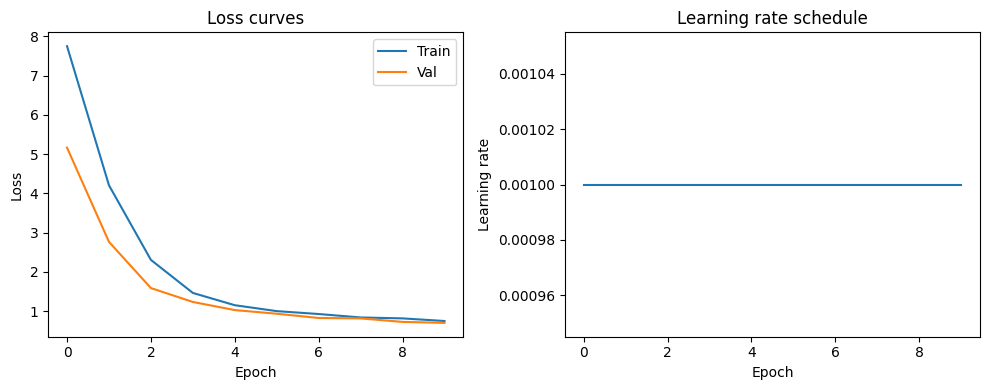

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss curves')

plt.subplot(1, 2, 2)
plt.plot(history['lr'])
plt.xlabel('Epoch')
plt.ylabel('Learning rate')
plt.title('Learning rate schedule')

plt.tight_layout()
plt.show()

### Full Model Training

In [ ]:
# ==== Model hyperparameters ====
EMBED_DIM = 256
NUM_HEADS = 8
NUM_DECODER_LAYERS = 3
FF_DIM = 512
DROPOUT = 0.1
MAX_LENGTH = 150
IMAGE_SIZE = 128

# ==== Training ====
BATCH_SIZE = 64          # drop to 16 or 8 if VRAM runs out
LEARNING_RATE = 1e-3
NUM_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 5
GRAD_CLIP = 1.0
USE_AMP = True
SEED = 42

# ==== Device ====
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
import json
import os

# --- config ---
BASE_SAVE_PATH = "/content/drive/Othercomputers/My Laptop/Desktop/ITAITA_Project/Model_Results"

CNN_ARCHITECTURES = {
    'ShallowCNN': ShallowCNN,
    'DeepCNN':    DeepCNN,
    'ResNetCNN':  ResNetCNN,
}

ENCODINGS = ['simple', 'bert']

# --- full datasets ---
full_train_dataset_simple = ImageCaptionDataset(train_data, encoding='simple')
full_val_dataset_simple   = ImageCaptionDataset(val_data,   encoding='simple')
full_train_dataset_bert   = ImageCaptionDataset(train_data, encoding='bert')
full_val_dataset_bert     = ImageCaptionDataset(val_data,   encoding='bert')

datasets = {
    'simple': (full_train_dataset_simple, full_val_dataset_simple),
    'bert':   (full_train_dataset_bert,   full_val_dataset_bert),
}

# --- results summary (populated after each run) ---
all_results = {}

for cnn_name, cnn_class in CNN_ARCHITECTURES.items():
    for encoding in ENCODINGS:

        run_name = f"{cnn_name}_{encoding}"
        save_dir = os.path.join(BASE_SAVE_PATH, run_name)
        os.makedirs(save_dir, exist_ok=True)

        print(f"\n{'='*60}")
        print(f"  Training: {run_name}")
        print(f"{'='*60}")

        # --- data ---
        train_dataset, val_dataset = datasets[encoding]
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
        val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

        # --- model ---
        torch.manual_seed(SEED)
        cnn = cnn_class().to(device)

        if encoding == 'bert':
            decoder = TransformerDecoder(
                vocab_size=bert_tokenizer.vocab_size,
                embed_dim=EMBED_DIM,
                max_length=MAX_LENGTH,
                num_heads=NUM_HEADS,
                N_layers=NUM_DECODER_LAYERS,
                ff_dim=FF_DIM,
                dropout=DROPOUT,
                use_bert=True
            ).to(device)
        else:
            decoder = TransformerDecoder(
                vocab_size=len(word2idx),
                embed_dim=EMBED_DIM,
                max_length=MAX_LENGTH,
                num_heads=NUM_HEADS,
                N_layers=NUM_DECODER_LAYERS,
                ff_dim=FF_DIM,
                dropout=DROPOUT,
                use_bert=False
            ).to(device)

        # --- training setup ---
        optimizer = torch.optim.Adam(
            list(cnn.parameters()) + list(decoder.parameters()),
            lr=LEARNING_RATE
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', patience=3, factor=0.5
        )
        criterion = nn.CrossEntropyLoss(ignore_index=0)
        scaler    = torch.amp.GradScaler('cuda') if USE_AMP and torch.cuda.is_available() else None

        # --- train ---
        history = train(
            cnn, decoder,
            train_loader, val_loader,
            optimizer, scheduler, criterion, device,
            num_epochs=NUM_EPOCHS,
            patience=EARLY_STOPPING_PATIENCE,
            scaler=scaler,
            save_path=os.path.join(save_dir, "best_model.pt")
        )

        # --- save history (for loss plots) ---
        history_path = os.path.join(save_dir, "history.json")
        with open(history_path, 'w') as f:
            json.dump(history, f, indent=2)
        print(f"  History saved to {history_path}")

        # --- save config ---
        config = {
            'cnn_architecture': cnn_name,
            'encoding':         encoding,
            'vocab_size':       bert_tokenizer.vocab_size if encoding == 'bert' else len(word2idx),
            'embed_dim':        EMBED_DIM,
            'num_heads':        NUM_HEADS,
            'num_layers':       NUM_DECODER_LAYERS,
            'ff_dim':           FF_DIM,
            'dropout':          DROPOUT,
            'max_length':       MAX_LENGTH,
            'batch_size':       BATCH_SIZE,
            'learning_rate':    LEARNING_RATE,
            'seed':             SEED,
            'best_val_loss':    min(history['val_loss']),
            'epochs_trained':   len(history['val_loss']),
        }
        config_path = os.path.join(save_dir, "config.json")
        with open(config_path, 'w') as f:
            json.dump(config, f, indent=2)

        # --- store summary ---
        all_results[run_name] = {
            'best_val_loss':  min(history['val_loss']),
            'epochs_trained': len(history['val_loss']),
            'save_dir':       save_dir,
        }

        print(f"  Best val loss: {min(history['val_loss']):.4f} | Epochs trained: {len(history['val_loss'])}")

# --- save overall summary ---
summary_path = os.path.join(BASE_SAVE_PATH, "all_results_summary.json")
with open(summary_path, 'w') as f:
    json.dump(all_results, f, indent=2)

print(f"\n{'='*60}")
print("All runs complete. Summary:")
for run_name, result in all_results.items():
    print(f"  {run_name:30s} | best val loss: {result['best_val_loss']:.4f} | epochs: {result['epochs_trained']}")
print(f"\nSummary saved to {summary_path}")


  Training: ShallowCNN_simple


Epoch 1/50 | Train Loss: 1.5301 | Val Loss: 0.9932 | LR: 1.00e-03
  Model saved ✅


Epoch 2/50 | Train Loss: 0.9728 | Val Loss: 0.8757 | LR: 1.00e-03
  Model saved ✅


Epoch 3/50 | Train Loss: 0.8751 | Val Loss: 0.8016 | LR: 1.00e-03
  Model saved ✅


Epoch 4/50 | Train Loss: 0.8057 | Val Loss: 0.7590 | LR: 1.00e-03
  Model saved ✅


Epoch 5/50 | Train Loss: 0.7661 | Val Loss: 0.7267 | LR: 1.00e-03
  Model saved ✅


Epoch 6/50 | Train Loss: 0.7347 | Val Loss: 0.7142 | LR: 1.00e-03
  Model saved ✅


Epoch 7/50 | Train Loss: 0.7126 | Val Loss: 0.6889 | LR: 1.00e-03
  Model saved ✅


Epoch 8/50 | Train Loss: 0.6911 | Val Loss: 0.6751 | LR: 1.00e-03
  Model saved ✅


Epoch 9/50 | Train Loss: 0.6732 | Val Loss: 0.6567 | LR: 1.00e-03
  Model saved ✅


Epoch 10/50 | Train Loss: 0.6549 | Val Loss: 0.6572 | LR: 1.00e-03
  No improvement (1/5)


Epoch 11/50 | Train Loss: 0.6390 | Val Loss: 0.6449 | LR: 1.00e-03
  Model saved ✅


Epoch 12/50 | Train Loss: 0.6247 | Val Loss: 0.6286 | LR: 1.00e-03
  Model saved ✅


Epoch 13/50 | Train Loss: 0.6139 | Val Loss: 0.6237 | LR: 1.00e-03
  Model saved ✅


Epoch 14/50 | Train Loss: 0.6017 | Val Loss: 0.6239 | LR: 1.00e-03
  No improvement (1/5)


Epoch 15/50 | Train Loss: 0.5904 | Val Loss: 0.6114 | LR: 1.00e-03
  Model saved ✅


Epoch 16/50 | Train Loss: 0.5764 | Val Loss: 0.5968 | LR: 1.00e-03
  Model saved ✅


Epoch 17/50 | Train Loss: 0.5674 | Val Loss: 0.6063 | LR: 1.00e-03
  No improvement (1/5)


Epoch 18/50 | Train Loss: 0.5572 | Val Loss: 0.5964 | LR: 1.00e-03
  Model saved ✅


Epoch 19/50 | Train Loss: 0.5451 | Val Loss: 0.5995 | LR: 1.00e-03
  No improvement (1/5)


Epoch 20/50 | Train Loss: 0.5395 | Val Loss: 0.5882 | LR: 1.00e-03
  Model saved ✅


Epoch 21/50 | Train Loss: 0.5293 | Val Loss: 0.5893 | LR: 1.00e-03
  No improvement (1/5)


Epoch 22/50 | Train Loss: 0.5208 | Val Loss: 0.5915 | LR: 1.00e-03
  No improvement (2/5)


Epoch 23/50 | Train Loss: 0.5160 | Val Loss: 0.6085 | LR: 1.00e-03
  No improvement (3/5)


Epoch 24/50 | Train Loss: 0.5057 | Val Loss: 0.5860 | LR: 1.00e-03
  Model saved ✅


Epoch 25/50 | Train Loss: 0.4977 | Val Loss: 0.5943 | LR: 1.00e-03
  No improvement (1/5)


Epoch 26/50 | Train Loss: 0.4902 | Val Loss: 0.6157 | LR: 1.00e-03
  No improvement (2/5)


Epoch 27/50 | Train Loss: 0.4886 | Val Loss: 0.5931 | LR: 1.00e-03
  No improvement (3/5)


Epoch 28/50 | Train Loss: 0.4784 | Val Loss: 0.5906 | LR: 5.00e-04
  No improvement (4/5)


Epoch 29/50 | Train Loss: 0.4295 | Val Loss: 0.5862 | LR: 5.00e-04
  No improvement (5/5)
Early stopping at epoch 29
  History saved to /content/drive/Othercomputers/My Laptop/Desktop/ITAITA_Project/Model_Results/ShallowCNN_simple/history.json
  Best val loss: 0.5860 | Epochs trained: 29

  Training: ShallowCNN_bert


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/50 | Train Loss: 1.5879 | Val Loss: 0.8709 | LR: 1.00e-03
  Model saved ✅


Epoch 2/50 | Train Loss: 0.8278 | Val Loss: 0.7505 | LR: 1.00e-03
  Model saved ✅


Epoch 3/50 | Train Loss: 0.7381 | Val Loss: 0.7025 | LR: 1.00e-03
  Model saved ✅


Epoch 4/50 | Train Loss: 0.7028 | Val Loss: 0.6789 | LR: 1.00e-03
  Model saved ✅


Epoch 5/50 | Train Loss: 0.6781 | Val Loss: 0.6642 | LR: 1.00e-03
  Model saved ✅


Epoch 6/50 | Train Loss: 0.6596 | Val Loss: 0.6407 | LR: 1.00e-03
  Model saved ✅


Epoch 7/50 | Train Loss: 0.6397 | Val Loss: 0.6241 | LR: 1.00e-03
  Model saved ✅


Epoch 8/50 | Train Loss: 0.6255 | Val Loss: 0.6077 | LR: 1.00e-03
  Model saved ✅


Epoch 9/50 | Train Loss: 0.6152 | Val Loss: 0.5974 | LR: 1.00e-03
  Model saved ✅


Epoch 10/50 | Train Loss: 0.6047 | Val Loss: 0.5866 | LR: 1.00e-03
  Model saved ✅


Epoch 11/50 | Train Loss: 0.5925 | Val Loss: 0.5785 | LR: 1.00e-03
  Model saved ✅


Epoch 12/50 | Train Loss: 0.5811 | Val Loss: 0.5744 | LR: 1.00e-03
  Model saved ✅


Epoch 13/50 | Train Loss: 0.5718 | Val Loss: 0.5568 | LR: 1.00e-03
  Model saved ✅


Epoch 14/50 | Train Loss: 0.5613 | Val Loss: 0.5526 | LR: 1.00e-03
  Model saved ✅


Epoch 15/50 | Train Loss: 0.5519 | Val Loss: 0.5495 | LR: 1.00e-03
  Model saved ✅


Epoch 16/50 | Train Loss: 0.5435 | Val Loss: 0.5401 | LR: 1.00e-03
  Model saved ✅


Epoch 17/50 | Train Loss: 0.5375 | Val Loss: 0.5323 | LR: 1.00e-03
  Model saved ✅


Epoch 18/50 | Train Loss: 0.5281 | Val Loss: 0.5213 | LR: 1.00e-03
  Model saved ✅


Epoch 19/50 | Train Loss: 0.5218 | Val Loss: 0.5264 | LR: 1.00e-03
  No improvement (1/5)


Epoch 20/50 | Train Loss: 0.5147 | Val Loss: 0.5178 | LR: 1.00e-03
  Model saved ✅


Epoch 21/50 | Train Loss: 0.5085 | Val Loss: 0.5217 | LR: 1.00e-03
  No improvement (1/5)


Epoch 22/50 | Train Loss: 0.5033 | Val Loss: 0.5083 | LR: 1.00e-03
  Model saved ✅


Epoch 23/50 | Train Loss: 0.4952 | Val Loss: 0.5165 | LR: 1.00e-03
  No improvement (1/5)


Epoch 24/50 | Train Loss: 0.4897 | Val Loss: 0.5100 | LR: 1.00e-03
  No improvement (2/5)


Epoch 25/50 | Train Loss: 0.4892 | Val Loss: 0.5137 | LR: 1.00e-03
  No improvement (3/5)


Epoch 26/50 | Train Loss: 0.4819 | Val Loss: 0.5127 | LR: 5.00e-04
  No improvement (4/5)


Epoch 27/50 | Train Loss: 0.4475 | Val Loss: 0.4793 | LR: 5.00e-04
  Model saved ✅


Epoch 28/50 | Train Loss: 0.4328 | Val Loss: 0.4865 | LR: 5.00e-04
  No improvement (1/5)


Epoch 29/50 | Train Loss: 0.4261 | Val Loss: 0.4846 | LR: 5.00e-04
  No improvement (2/5)


Epoch 30/50 | Train Loss: 0.4200 | Val Loss: 0.4804 | LR: 5.00e-04
  No improvement (3/5)


Epoch 31/50 | Train Loss: 0.4139 | Val Loss: 0.4886 | LR: 2.50e-04
  No improvement (4/5)


Epoch 32/50 | Train Loss: 0.3919 | Val Loss: 0.4795 | LR: 2.50e-04
  No improvement (5/5)
Early stopping at epoch 32
  History saved to /content/drive/Othercomputers/My Laptop/Desktop/ITAITA_Project/Model_Results/ShallowCNN_bert/history.json
  Best val loss: 0.4793 | Epochs trained: 32

  Training: DeepCNN_simple


Epoch 1/50 | Train Loss: 1.5294 | Val Loss: 1.0066 | LR: 1.00e-03
  Model saved ✅


Epoch 2/50 | Train Loss: 0.9824 | Val Loss: 0.8968 | LR: 1.00e-03
  Model saved ✅


Epoch 3/50 | Train Loss: 0.8988 | Val Loss: 0.8248 | LR: 1.00e-03
  Model saved ✅


Epoch 4/50 | Train Loss: 0.8279 | Val Loss: 0.7821 | LR: 1.00e-03
  Model saved ✅


Epoch 5/50 | Train Loss: 0.7929 | Val Loss: 0.7676 | LR: 1.00e-03
  Model saved ✅


Epoch 6/50 | Train Loss: 0.7626 | Val Loss: 0.7384 | LR: 1.00e-03
  Model saved ✅


Epoch 7/50 | Train Loss: 0.7404 | Val Loss: 0.7250 | LR: 1.00e-03
  Model saved ✅


Epoch 8/50 | Train Loss: 0.7205 | Val Loss: 0.7093 | LR: 1.00e-03
  Model saved ✅


Epoch 9/50 | Train Loss: 0.7028 | Val Loss: 0.6918 | LR: 1.00e-03
  Model saved ✅


Epoch 10/50 | Train Loss: 0.6892 | Val Loss: 0.6780 | LR: 1.00e-03
  Model saved ✅


Epoch 11/50 | Train Loss: 0.6722 | Val Loss: 0.6621 | LR: 1.00e-03
  Model saved ✅


Epoch 12/50 | Train Loss: 0.6557 | Val Loss: 0.6523 | LR: 1.00e-03
  Model saved ✅


Epoch 13/50 | Train Loss: 0.6378 | Val Loss: 0.6408 | LR: 1.00e-03
  Model saved ✅


Epoch 14/50 | Train Loss: 0.6185 | Val Loss: 0.6140 | LR: 1.00e-03
  Model saved ✅


Epoch 15/50 | Train Loss: 0.5995 | Val Loss: 0.5995 | LR: 1.00e-03
  Model saved ✅


Epoch 16/50 | Train Loss: 0.5851 | Val Loss: 0.6053 | LR: 1.00e-03
  No improvement (1/5)


Epoch 17/50 | Train Loss: 0.5694 | Val Loss: 0.5795 | LR: 1.00e-03
  Model saved ✅


Epoch 18/50 | Train Loss: 0.5507 | Val Loss: 0.5652 | LR: 1.00e-03
  Model saved ✅


Epoch 19/50 | Train Loss: 0.5379 | Val Loss: 0.5532 | LR: 1.00e-03
  Model saved ✅


Epoch 20/50 | Train Loss: 0.5218 | Val Loss: 0.5435 | LR: 1.00e-03
  Model saved ✅


Epoch 21/50 | Train Loss: 0.5122 | Val Loss: 0.5404 | LR: 1.00e-03
  Model saved ✅


Epoch 22/50 | Train Loss: 0.4973 | Val Loss: 0.5393 | LR: 1.00e-03
  Model saved ✅


Epoch 23/50 | Train Loss: 0.4860 | Val Loss: 0.5377 | LR: 1.00e-03
  Model saved ✅


Epoch 24/50 | Train Loss: 0.4731 | Val Loss: 0.5245 | LR: 1.00e-03
  Model saved ✅


Epoch 25/50 | Train Loss: 0.4630 | Val Loss: 0.5169 | LR: 1.00e-03
  Model saved ✅


Epoch 26/50 | Train Loss: 0.4494 | Val Loss: 0.5187 | LR: 1.00e-03
  No improvement (1/5)


Epoch 27/50 | Train Loss: 0.4373 | Val Loss: 0.5062 | LR: 1.00e-03
  Model saved ✅


Epoch 28/50 | Train Loss: 0.4266 | Val Loss: 0.5118 | LR: 1.00e-03
  No improvement (1/5)


Epoch 29/50 | Train Loss: 0.4142 | Val Loss: 0.4938 | LR: 1.00e-03
  Model saved ✅


Epoch 30/50 | Train Loss: 0.4020 | Val Loss: 0.4950 | LR: 1.00e-03
  No improvement (1/5)


Epoch 31/50 | Train Loss: 0.3951 | Val Loss: 0.4966 | LR: 1.00e-03
  No improvement (2/5)


Epoch 32/50 | Train Loss: 0.3816 | Val Loss: 0.4876 | LR: 1.00e-03
  Model saved ✅


Epoch 33/50 | Train Loss: 0.3717 | Val Loss: 0.4927 | LR: 1.00e-03
  No improvement (1/5)


Epoch 34/50 | Train Loss: 0.3605 | Val Loss: 0.4869 | LR: 1.00e-03
  Model saved ✅


Epoch 35/50 | Train Loss: 0.3540 | Val Loss: 0.4882 | LR: 1.00e-03
  No improvement (1/5)


Epoch 36/50 | Train Loss: 0.3475 | Val Loss: 0.4836 | LR: 1.00e-03
  Model saved ✅


Epoch 37/50 | Train Loss: 0.3354 | Val Loss: 0.4768 | LR: 1.00e-03
  Model saved ✅


Epoch 38/50 | Train Loss: 0.3258 | Val Loss: 0.4835 | LR: 1.00e-03
  No improvement (1/5)


Epoch 39/50 | Train Loss: 0.3232 | Val Loss: 0.4793 | LR: 1.00e-03
  No improvement (2/5)


Epoch 40/50 | Train Loss: 0.3170 | Val Loss: 0.4829 | LR: 1.00e-03
  No improvement (3/5)


Epoch 41/50 | Train Loss: 0.3090 | Val Loss: 0.4862 | LR: 5.00e-04
  No improvement (4/5)


Epoch 42/50 | Train Loss: 0.2633 | Val Loss: 0.4826 | LR: 5.00e-04
  No improvement (5/5)
Early stopping at epoch 42
  History saved to /content/drive/Othercomputers/My Laptop/Desktop/ITAITA_Project/Model_Results/DeepCNN_simple/history.json
  Best val loss: 0.4768 | Epochs trained: 42

  Training: DeepCNN_bert


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/50 | Train Loss: 1.5931 | Val Loss: 0.8662 | LR: 1.00e-03
  Model saved ✅


Epoch 2/50 | Train Loss: 0.8316 | Val Loss: 0.7589 | LR: 1.00e-03
  Model saved ✅


Epoch 3/50 | Train Loss: 0.7432 | Val Loss: 0.7089 | LR: 1.00e-03
  Model saved ✅


Epoch 4/50 | Train Loss: 0.7116 | Val Loss: 0.6787 | LR: 1.00e-03
  Model saved ✅


Epoch 5/50 | Train Loss: 0.6785 | Val Loss: 0.6565 | LR: 1.00e-03
  Model saved ✅


Epoch 6/50 | Train Loss: 0.6643 | Val Loss: 0.6482 | LR: 1.00e-03
  Model saved ✅


Epoch 7/50 | Train Loss: 0.6501 | Val Loss: 0.6374 | LR: 1.00e-03
  Model saved ✅


Epoch 8/50 | Train Loss: 0.6375 | Val Loss: 0.6321 | LR: 1.00e-03
  Model saved ✅


Epoch 9/50 | Train Loss: 0.6254 | Val Loss: 0.6120 | LR: 1.00e-03
  Model saved ✅


Epoch 10/50 | Train Loss: 0.6164 | Val Loss: 0.6160 | LR: 1.00e-03
  No improvement (1/5)


Epoch 11/50 | Train Loss: 0.6018 | Val Loss: 0.5823 | LR: 1.00e-03
  Model saved ✅


Epoch 12/50 | Train Loss: 0.5867 | Val Loss: 0.5816 | LR: 1.00e-03
  Model saved ✅


Epoch 13/50 | Train Loss: 0.5739 | Val Loss: 0.5563 | LR: 1.00e-03
  Model saved ✅


Epoch 14/50 | Train Loss: 0.5584 | Val Loss: 0.5437 | LR: 1.00e-03
  Model saved ✅


Epoch 15/50 | Train Loss: 0.5475 | Val Loss: 0.5307 | LR: 1.00e-03
  Model saved ✅


Epoch 16/50 | Train Loss: 0.5340 | Val Loss: 0.5232 | LR: 1.00e-03
  Model saved ✅


Epoch 17/50 | Train Loss: 0.5187 | Val Loss: 0.5060 | LR: 1.00e-03
  Model saved ✅


Epoch 18/50 | Train Loss: 0.5076 | Val Loss: 0.4943 | LR: 1.00e-03
  Model saved ✅


Epoch 19/50 | Train Loss: 0.4949 | Val Loss: 0.4966 | LR: 1.00e-03
  No improvement (1/5)


Epoch 20/50 | Train Loss: 0.4869 | Val Loss: 0.4748 | LR: 1.00e-03
  Model saved ✅


Epoch 21/50 | Train Loss: 0.4768 | Val Loss: 0.4798 | LR: 1.00e-03
  No improvement (1/5)


Epoch 22/50 | Train Loss: 0.4656 | Val Loss: 0.4598 | LR: 1.00e-03
  Model saved ✅


Epoch 23/50 | Train Loss: 0.4531 | Val Loss: 0.4551 | LR: 1.00e-03
  Model saved ✅


Epoch 24/50 | Train Loss: 0.4449 | Val Loss: 0.4428 | LR: 1.00e-03
  Model saved ✅


Epoch 25/50 | Train Loss: 0.4349 | Val Loss: 0.4368 | LR: 1.00e-03
  Model saved ✅


Epoch 26/50 | Train Loss: 0.4237 | Val Loss: 0.4313 | LR: 1.00e-03
  Model saved ✅


Epoch 27/50 | Train Loss: 0.4166 | Val Loss: 0.4323 | LR: 1.00e-03
  No improvement (1/5)


Epoch 28/50 | Train Loss: 0.4099 | Val Loss: 0.4153 | LR: 1.00e-03
  Model saved ✅


Epoch 29/50 | Train Loss: 0.3998 | Val Loss: 0.4154 | LR: 1.00e-03
  No improvement (1/5)


Epoch 30/50 | Train Loss: 0.3939 | Val Loss: 0.4040 | LR: 1.00e-03
  Model saved ✅


Epoch 31/50 | Train Loss: 0.3846 | Val Loss: 0.4024 | LR: 1.00e-03
  Model saved ✅


Epoch 32/50 | Train Loss: 0.3809 | Val Loss: 0.4096 | LR: 1.00e-03
  No improvement (1/5)


Epoch 33/50 | Train Loss: 0.3711 | Val Loss: 0.3997 | LR: 1.00e-03
  Model saved ✅


Epoch 34/50 | Train Loss: 0.3673 | Val Loss: 0.3883 | LR: 1.00e-03
  Model saved ✅


Epoch 35/50 | Train Loss: 0.3587 | Val Loss: 0.3939 | LR: 1.00e-03
  No improvement (1/5)


Epoch 36/50 | Train Loss: 0.3536 | Val Loss: 0.3899 | LR: 1.00e-03
  No improvement (2/5)


Epoch 37/50 | Train Loss: 0.3494 | Val Loss: 0.3833 | LR: 1.00e-03
  Model saved ✅


Epoch 38/50 | Train Loss: 0.3406 | Val Loss: 0.3863 | LR: 1.00e-03
  No improvement (1/5)


Epoch 39/50 | Train Loss: 0.3373 | Val Loss: 0.3768 | LR: 1.00e-03
  Model saved ✅


Epoch 40/50 | Train Loss: 0.3305 | Val Loss: 0.3737 | LR: 1.00e-03
  Model saved ✅


Epoch 41/50 | Train Loss: 0.3244 | Val Loss: 0.3774 | LR: 1.00e-03
  No improvement (1/5)


Epoch 42/50 | Train Loss: 0.3176 | Val Loss: 0.3804 | LR: 1.00e-03
  No improvement (2/5)


Epoch 43/50 | Train Loss: 0.3149 | Val Loss: 0.3790 | LR: 1.00e-03
  No improvement (3/5)


Epoch 44/50 | Train Loss: 0.3091 | Val Loss: 0.3717 | LR: 1.00e-03
  Model saved ✅


Epoch 45/50 | Train Loss: 0.3070 | Val Loss: 0.3884 | LR: 1.00e-03
  No improvement (1/5)


Epoch 46/50 | Train Loss: 0.3018 | Val Loss: 0.3688 | LR: 1.00e-03
  Model saved ✅


Epoch 47/50 | Train Loss: 0.2953 | Val Loss: 0.3736 | LR: 1.00e-03
  No improvement (1/5)


Epoch 48/50 | Train Loss: 0.2937 | Val Loss: 0.3757 | LR: 1.00e-03
  No improvement (2/5)


Epoch 49/50 | Train Loss: 0.2904 | Val Loss: 0.3705 | LR: 1.00e-03
  No improvement (3/5)


Epoch 50/50 | Train Loss: 0.2868 | Val Loss: 0.3699 | LR: 5.00e-04
  No improvement (4/5)
  History saved to /content/drive/Othercomputers/My Laptop/Desktop/ITAITA_Project/Model_Results/DeepCNN_bert/history.json
  Best val loss: 0.3688 | Epochs trained: 50

  Training: ResNetCNN_simple


Epoch 1/50 | Train Loss: 1.5322 | Val Loss: 0.9799 | LR: 1.00e-03
  Model saved ✅


Epoch 2/50 | Train Loss: 0.9525 | Val Loss: 0.8530 | LR: 1.00e-03
  Model saved ✅


Epoch 3/50 | Train Loss: 0.8702 | Val Loss: 0.7938 | LR: 1.00e-03
  Model saved ✅


Epoch 4/50 | Train Loss: 0.7916 | Val Loss: 0.7407 | LR: 1.00e-03
  Model saved ✅


Epoch 5/50 | Train Loss: 0.7461 | Val Loss: 0.7121 | LR: 1.00e-03
  Model saved ✅


Epoch 6/50 | Train Loss: 0.7154 | Val Loss: 0.6835 | LR: 1.00e-03
  Model saved ✅


Epoch 7/50 | Train Loss: 0.6825 | Val Loss: 0.6568 | LR: 1.00e-03
  Model saved ✅


Epoch 8/50 | Train Loss: 0.6543 | Val Loss: 0.6252 | LR: 1.00e-03
  Model saved ✅


Epoch 9/50 | Train Loss: 0.6266 | Val Loss: 0.6055 | LR: 1.00e-03
  Model saved ✅


Epoch 10/50 | Train Loss: 0.6056 | Val Loss: 0.6058 | LR: 1.00e-03
  No improvement (1/5)


Epoch 11/50 | Train Loss: 0.5861 | Val Loss: 0.5658 | LR: 1.00e-03
  Model saved ✅


Epoch 12/50 | Train Loss: 0.5671 | Val Loss: 0.5652 | LR: 1.00e-03
  Model saved ✅


Epoch 13/50 | Train Loss: 0.5515 | Val Loss: 0.6455 | LR: 1.00e-03
  No improvement (1/5)


Epoch 14/50 | Train Loss: 0.5316 | Val Loss: 0.5391 | LR: 1.00e-03
  Model saved ✅


Epoch 15/50 | Train Loss: 0.5164 | Val Loss: 0.5292 | LR: 1.00e-03
  Model saved ✅


Epoch 16/50 | Train Loss: 0.4955 | Val Loss: 0.5328 | LR: 1.00e-03
  No improvement (1/5)


Epoch 17/50 | Train Loss: 0.4777 | Val Loss: 0.5013 | LR: 1.00e-03
  Model saved ✅


Epoch 18/50 | Train Loss: 0.4637 | Val Loss: 0.4949 | LR: 1.00e-03
  Model saved ✅


Epoch 19/50 | Train Loss: 0.4483 | Val Loss: 0.4711 | LR: 1.00e-03
  Model saved ✅


Epoch 20/50 | Train Loss: 0.4336 | Val Loss: 0.4649 | LR: 1.00e-03
  Model saved ✅


Epoch 21/50 | Train Loss: 0.4235 | Val Loss: 0.4759 | LR: 1.00e-03
  No improvement (1/5)


Epoch 22/50 | Train Loss: 0.4116 | Val Loss: 0.4753 | LR: 1.00e-03
  No improvement (2/5)


Epoch 23/50 | Train Loss: 0.4020 | Val Loss: 0.4617 | LR: 1.00e-03
  Model saved ✅


Epoch 24/50 | Train Loss: 0.3938 | Val Loss: 0.4603 | LR: 1.00e-03
  Model saved ✅


Epoch 25/50 | Train Loss: 0.3802 | Val Loss: 0.4866 | LR: 1.00e-03
  No improvement (1/5)


Epoch 26/50 | Train Loss: 0.3726 | Val Loss: 0.4595 | LR: 1.00e-03
  Model saved ✅


Epoch 27/50 | Train Loss: 0.3664 | Val Loss: 0.4692 | LR: 1.00e-03
  No improvement (1/5)


Epoch 28/50 | Train Loss: 0.3580 | Val Loss: 0.4699 | LR: 1.00e-03
  No improvement (2/5)


Epoch 29/50 | Train Loss: 0.3501 | Val Loss: 0.7497 | LR: 1.00e-03
  No improvement (3/5)


Epoch 30/50 | Train Loss: 0.3424 | Val Loss: 0.4465 | LR: 1.00e-03
  Model saved ✅


Epoch 31/50 | Train Loss: 0.3356 | Val Loss: 0.4479 | LR: 1.00e-03
  No improvement (1/5)


Epoch 32/50 | Train Loss: 0.3300 | Val Loss: 0.6061 | LR: 1.00e-03
  No improvement (2/5)


Epoch 33/50 | Train Loss: 0.3224 | Val Loss: 0.4547 | LR: 1.00e-03
  No improvement (3/5)


Epoch 34/50 | Train Loss: 0.3178 | Val Loss: 2.4327 | LR: 5.00e-04
  No improvement (4/5)


Epoch 35/50 | Train Loss: 0.2667 | Val Loss: 0.4503 | LR: 5.00e-04
  No improvement (5/5)
Early stopping at epoch 35
  History saved to /content/drive/Othercomputers/My Laptop/Desktop/ITAITA_Project/Model_Results/ResNetCNN_simple/history.json
  Best val loss: 0.4465 | Epochs trained: 35

  Training: ResNetCNN_bert


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/50 | Train Loss: 1.5922 | Val Loss: 0.8943 | LR: 1.00e-03
  Model saved ✅


Epoch 2/50 | Train Loss: 0.8047 | Val Loss: 0.7274 | LR: 1.00e-03
  Model saved ✅


Epoch 3/50 | Train Loss: 0.7205 | Val Loss: 0.6782 | LR: 1.00e-03
  Model saved ✅


Epoch 4/50 | Train Loss: 0.6844 | Val Loss: 0.6858 | LR: 1.00e-03
  No improvement (1/5)


Epoch 5/50 | Train Loss: 0.6629 | Val Loss: 0.6473 | LR: 1.00e-03
  Model saved ✅


Epoch 6/50 | Train Loss: 0.6426 | Val Loss: 0.6265 | LR: 1.00e-03
  Model saved ✅


Epoch 7/50 | Train Loss: 0.6164 | Val Loss: 0.5867 | LR: 1.00e-03
  Model saved ✅


Epoch 8/50 | Train Loss: 0.5882 | Val Loss: 0.5680 | LR: 1.00e-03
  Model saved ✅


Epoch 9/50 | Train Loss: 0.5701 | Val Loss: 0.5541 | LR: 1.00e-03
  Model saved ✅


Epoch 10/50 | Train Loss: 0.5436 | Val Loss: 0.5211 | LR: 1.00e-03
  Model saved ✅


Epoch 11/50 | Train Loss: 0.5240 | Val Loss: 0.4948 | LR: 1.00e-03
  Model saved ✅


Epoch 12/50 | Train Loss: 0.5037 | Val Loss: 0.4943 | LR: 1.00e-03
  Model saved ✅


Epoch 13/50 | Train Loss: 0.4895 | Val Loss: 0.4704 | LR: 1.00e-03
  Model saved ✅


Epoch 14/50 | Train Loss: 0.4737 | Val Loss: 0.4619 | LR: 1.00e-03
  Model saved ✅


Epoch 15/50 | Train Loss: 0.4568 | Val Loss: 0.4474 | LR: 1.00e-03
  Model saved ✅


Epoch 16/50 | Train Loss: 0.4435 | Val Loss: 0.4329 | LR: 1.00e-03
  Model saved ✅


Epoch 17/50 | Train Loss: 0.4335 | Val Loss: 0.4544 | LR: 1.00e-03
  No improvement (1/5)


Epoch 18/50 | Train Loss: 0.4211 | Val Loss: 0.4196 | LR: 1.00e-03
  Model saved ✅


Epoch 19/50 | Train Loss: 0.4148 | Val Loss: 0.4090 | LR: 1.00e-03
  Model saved ✅


Epoch 20/50 | Train Loss: 0.3996 | Val Loss: 0.4023 | LR: 1.00e-03
  Model saved ✅


Epoch 21/50 | Train Loss: 0.3907 | Val Loss: 0.3954 | LR: 1.00e-03
  Model saved ✅


Epoch 22/50 | Train Loss: 0.3827 | Val Loss: 0.4074 | LR: 1.00e-03
  No improvement (1/5)


Epoch 23/50 | Train Loss: 0.3754 | Val Loss: 0.3863 | LR: 1.00e-03
  Model saved ✅


Epoch 24/50 | Train Loss: 0.3681 | Val Loss: 0.3876 | LR: 1.00e-03
  No improvement (1/5)


Epoch 25/50 | Train Loss: 0.3603 | Val Loss: 0.4313 | LR: 1.00e-03
  No improvement (2/5)


Epoch 26/50 | Train Loss: 0.3556 | Val Loss: 0.4847 | LR: 1.00e-03
  No improvement (3/5)


Epoch 27/50 | Train Loss: 0.3461 | Val Loss: 0.3923 | LR: 5.00e-04
  No improvement (4/5)


Epoch 28/50 | Train Loss: 0.3072 | Val Loss: 0.3554 | LR: 5.00e-04
  Model saved ✅


Epoch 29/50 | Train Loss: 0.2918 | Val Loss: 0.3737 | LR: 5.00e-04
  No improvement (1/5)


Epoch 30/50 | Train Loss: 0.2845 | Val Loss: 0.3662 | LR: 5.00e-04
  No improvement (2/5)


Epoch 31/50 | Train Loss: 0.2792 | Val Loss: 0.3659 | LR: 5.00e-04
  No improvement (3/5)


Epoch 32/50 | Train Loss: 0.2734 | Val Loss: 0.3825 | LR: 2.50e-04
  No improvement (4/5)


Epoch 33/50 | Train Loss: 0.2497 | Val Loss: 0.3679 | LR: 2.50e-04
  No improvement (5/5)
Early stopping at epoch 33
  History saved to /content/drive/Othercomputers/My Laptop/Desktop/ITAITA_Project/Model_Results/ResNetCNN_bert/history.json
  Best val loss: 0.3554 | Epochs trained: 33

All runs complete. Summary:
  ShallowCNN_simple              | best val loss: 0.5860 | epochs: 29
  ShallowCNN_bert                | best val loss: 0.4793 | epochs: 32
  DeepCNN_simple                 | best val loss: 0.4768 | epochs: 42
  DeepCNN_bert                   | best val loss: 0.3688 | epochs: 50
  ResNetCNN_simple               | best val loss: 0.4465 | epochs: 35
  ResNetCNN_bert                 | best val loss: 0.3554 | epochs: 33

Summary saved to /content/drive/Othercomputers/My Laptop/Desktop/ITAITA_Project/Model_Results/all_results_summary.json


## Eval

In [ ]:
CONFIG_PATH      = "/content/drive/Othercomputers/My Laptop/Desktop/ITAITA_Project/Config/"
MODEL_RESULTS    = "/content/drive/Othercomputers/My Laptop/Desktop/ITAITA_Project/Model_Results/"
MASTER_CSV_PATH    = "/content/drive/Othercomputers/My Laptop/Desktop/ITAITA_Project/Data/master_encoded_data.csv"
TEST_DATA_PATH   = "/content/drive/Othercomputers/My Laptop/Desktop/ITAITA_Project/Config/test_data_with_color_info.csv"

In [ ]:
with open(os.path.join(CONFIG_PATH, "word2idx.json")) as f:
    word2idx = json.load(f)
with open(os.path.join(CONFIG_PATH, "idx2word.json")) as f:
    idx2word = {int(k): v for k, v in json.load(f).items()}

In [ ]:
try:
  df = pd.read_csv(TEST_DATA_PATH)
except:
  df = pd.read_csv(MASTER_CSV_PATH)
test_data = df[df['split'] == 'test'].reset_index(drop=True)

In [ ]:
def detect_colour(path):
    try:
        return Image.open(path).mode == 'RGB'
    except Exception:
        return None

In [ ]:
if 'is_colour' not in test_data.columns:
    print("Detecting colour/BW...")
    test_data['is_colour'] = test_data['file_path'].apply(detect_colour)
    print(test_data['is_colour'].value_counts())
    # test_data.drop(columns=['Unnamed: 0'], inplace=True)
    # test_data.to_csv(os.path.join(CONFIG_PATH, "test_data_with_color_info.csv"), index=False)

In [ ]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.Lambda(lambda img: img.convert('RGB')),
    transforms.ToTensor(),
])

def load_image(path):
    img = Image.open(path)
    return transform(img)

In [ ]:
CNN_CLASSES = {
    'ShallowCNN': ShallowCNN,
    'DeepCNN':    DeepCNN,
    'ResNetCNN':  ResNetCNN,
}

RUN_NAMES = [
    'ShallowCNN_simple', 'ShallowCNN_bert',
    'DeepCNN_simple',    'DeepCNN_bert',
    'ResNetCNN_simple',  'ResNetCNN_bert',
]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
for run_name in RUN_NAMES:
    save_dir    = os.path.join(MODEL_RESULTS, run_name)
    pred_path   = os.path.join(save_dir, "predictions.csv")

    # skip if already done (safe to re-run after crash)
    # if os.path.exists(pred_path):
    #     print(f"[SKIP] {run_name} — predictions.csv already exists")
    #     continue

    print(f"\n{'─'*60}")
    print(f"Generating: {run_name}")

    # load config
    with open(os.path.join(save_dir, "config.json")) as f:
        config = json.load(f)

    encoding     = config['encoding']          # 'simple' or 'bert'
    cnn_arch     = config['cnn_architecture']  # 'ShallowCNN', 'DeepCNN', 'ResNetCNN'
    vocab_size   = config['vocab_size']

    # instantiate and load model
    cnn_model  = CNN_CLASSES[cnn_arch]().to(device)

    if encoding == 'bert':
        dec_model = TransformerDecoder(vocab_size=bert_tokenizer.vocab_size, use_bert=True).to(device)
    else:
        dec_model = TransformerDecoder(vocab_size=vocab_size).to(device)

    checkpoint = torch.load(os.path.join(save_dir, "best_model.pt"), map_location=device)
    cnn_model.load_state_dict(checkpoint['cnn'])
    dec_model.load_state_dict(checkpoint['decoder'])
    cnn_model.eval()
    dec_model.eval()
    print(f"  Weights loaded ✅  encoding={encoding}, arch={cnn_arch}, vocab={vocab_size}")

    # generate one prediction per test image
    records = []
    for _, row in tqdm(test_data.iterrows(), total=len(test_data), desc=run_name):
        image = load_image(row['file_path'])

        if encoding == 'bert':
            pred = generate(cnn_model, dec_model, image, device,
                            tokenizer=bert_tokenizer)
        else:
            pred = generate(cnn_model, dec_model, image, device,
                            word2idx=word2idx, idx2word=idx2word)

        records.append({
            'file_path':  row['file_path'],
            'dataset':    row['dataset'],
            'is_colour':  row['is_colour'],
            'reference':  row['text'],
            'prediction': pred,
        })

    pd.DataFrame(records).to_csv(pred_path, index=False)
    print(f"  Saved → {pred_path}")

print(f"\n{'='*60}")
print("All predictions generated ✅")


────────────────────────────────────────────────────────────
Generating: ShallowCNN_simple
  Weights loaded ✅  encoding=simple, arch=ShallowCNN, vocab=172


ShallowCNN_simple: 100%|██████████| 2238/2238 [16:23<00:00,  2.27it/s]


  Saved → /content/drive/Othercomputers/My Laptop/Desktop/ITAITA_Project/Model_Results/ShallowCNN_simple/predictions.csv

────────────────────────────────────────────────────────────
Generating: ShallowCNN_bert


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Weights loaded ✅  encoding=bert, arch=ShallowCNN, vocab=30522


ShallowCNN_bert: 100%|██████████| 2238/2238 [07:12<00:00,  5.17it/s]


  Saved → /content/drive/Othercomputers/My Laptop/Desktop/ITAITA_Project/Model_Results/ShallowCNN_bert/predictions.csv

────────────────────────────────────────────────────────────
Generating: DeepCNN_simple
  Weights loaded ✅  encoding=simple, arch=DeepCNN, vocab=172


DeepCNN_simple: 100%|██████████| 2238/2238 [04:56<00:00,  7.54it/s]


  Saved → /content/drive/Othercomputers/My Laptop/Desktop/ITAITA_Project/Model_Results/DeepCNN_simple/predictions.csv

────────────────────────────────────────────────────────────
Generating: DeepCNN_bert


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Weights loaded ✅  encoding=bert, arch=DeepCNN, vocab=30522


DeepCNN_bert: 100%|██████████| 2238/2238 [07:28<00:00,  4.99it/s]


  Saved → /content/drive/Othercomputers/My Laptop/Desktop/ITAITA_Project/Model_Results/DeepCNN_bert/predictions.csv

────────────────────────────────────────────────────────────
Generating: ResNetCNN_simple
  Weights loaded ✅  encoding=simple, arch=ResNetCNN, vocab=172


ResNetCNN_simple: 100%|██████████| 2238/2238 [04:40<00:00,  7.97it/s]


  Saved → /content/drive/Othercomputers/My Laptop/Desktop/ITAITA_Project/Model_Results/ResNetCNN_simple/predictions.csv

────────────────────────────────────────────────────────────
Generating: ResNetCNN_bert


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Weights loaded ✅  encoding=bert, arch=ResNetCNN, vocab=30522


ResNetCNN_bert: 100%|██████████| 2238/2238 [06:54<00:00,  5.39it/s]

  Saved → /content/drive/Othercomputers/My Laptop/Desktop/ITAITA_Project/Model_Results/ResNetCNN_bert/predictions.csv

All predictions generated ✅


In [ ]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from bert_score import score as bert_score_fn
import nltk

In [ ]:
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

MODEL_RESULTS = "/content/drive/Othercomputers/My Laptop/Desktop/ITAITA_Project/Model_Results/"
RUN_NAMES = [
    'ShallowCNN_simple', 'ShallowCNN_bert',
    'DeepCNN_simple',    'DeepCNN_bert',
    'ResNetCNN_simple',  'ResNetCNN_bert',
]
DATASETS = ['Shapes_Data', 'Numbers_Data', 'TicTacToe_Data']
smoothie = SmoothingFunction().method1

In [ ]:
def exact_match(ref, hyp):
    return float(ref.strip() == hyp.strip())

def bleu4(ref, hyp):
    ref_tokens = ref.strip().split()
    hyp_tokens = hyp.strip().split()
    if len(hyp_tokens) == 0:
        return 0.0
    return sentence_bleu([ref_tokens], hyp_tokens,
                         weights=(0.25, 0.25, 0.25, 0.25),
                         smoothing_function=smoothie)

def meteor(ref, hyp):
    ref_tokens = ref.strip().split()
    hyp_tokens = hyp.strip().split()
    if len(hyp_tokens) == 0:
        return 0.0
    return meteor_score([ref_tokens], hyp_tokens)

def compute_bertscore_batch(refs, hyps):
    # returns list of F1 scores
    P, R, F1 = bert_score_fn(hyps, refs, lang='en', verbose=False)
    return F1.tolist()

In [ ]:
def score_predictions(df):
    refs = df['reference'].fillna('').tolist()
    hyps = df['prediction'].fillna('').tolist()

    print("  Computing BLEU-4 and METEOR...")
    df = df.copy()
    df['exact_match'] = [exact_match(r, h) for r, h in zip(refs, hyps)]
    df['bleu4']       = [bleu4(r, h)       for r, h in zip(refs, hyps)]
    df['meteor']      = [meteor(r, h)      for r, h in zip(refs, hyps)]

    print("  Computing BERTScore (this may take a minute)...")
    df['bertscore']   = compute_bertscore_batch(refs, hyps)

    return df

In [ ]:
def aggregate(df):
    return {
        'exact_match': round(df['exact_match'].mean(), 4),
        'bleu4':       round(df['bleu4'].mean(), 4),
        'meteor':      round(df['meteor'].mean(), 4),
        'bertscore':   round(df['bertscore'].mean(), 4),
        'n':           len(df),
    }

In [ ]:
all_results = {}

for run_name in RUN_NAMES:
    pred_path = os.path.join(MODEL_RESULTS, run_name, "predictions.csv")
    if not os.path.exists(pred_path):
        print(f"[MISSING] {run_name} — run Cell 1 first")
        continue

    print(f"\n{'─'*60}")
    print(f"Scoring: {run_name}")
    df = pd.read_csv(pred_path)
    df = score_predictions(df)

    results = {}

    # overall
    results['overall'] = aggregate(df)

    # per dataset
    for ds in DATASETS:
        subset = df[df['dataset'] == ds]
        results[ds] = aggregate(subset)

        # colour vs B&W within each dataset
        results[f'{ds}_colour'] = aggregate(subset[subset['is_colour'] == True])
        results[f'{ds}_bw']     = aggregate(subset[subset['is_colour'] == False])

    all_results[run_name] = results
    print(f"  Done ✅  overall BLEU-4={results['overall']['bleu4']}  METEOR={results['overall']['meteor']}  BERTScore={results['overall']['bertscore']}")


────────────────────────────────────────────────────────────
Scoring: ShallowCNN_simple
  Computing BLEU-4 and METEOR...
  Computing BERTScore (this may take a minute)...


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Done ✅  overall BLEU-4=0.1398  METEOR=0.4065  BERTScore=0.9086

────────────────────────────────────────────────────────────
Scoring: ShallowCNN_bert
  Computing BLEU-4 and METEOR...
  Computing BERTScore (this may take a minute)...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Done ✅  overall BLEU-4=0.1542  METEOR=0.4236  BERTScore=0.9216

────────────────────────────────────────────────────────────
Scoring: DeepCNN_simple
  Computing BLEU-4 and METEOR...
  Computing BERTScore (this may take a minute)...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Done ✅  overall BLEU-4=0.1987  METEOR=0.4807  BERTScore=0.9183

────────────────────────────────────────────────────────────
Scoring: DeepCNN_bert
  Computing BLEU-4 and METEOR...
  Computing BERTScore (this may take a minute)...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Done ✅  overall BLEU-4=0.219  METEOR=0.4994  BERTScore=0.9292

────────────────────────────────────────────────────────────
Scoring: ResNetCNN_simple
  Computing BLEU-4 and METEOR...
  Computing BERTScore (this may take a minute)...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Done ✅  overall BLEU-4=0.1895  METEOR=0.4677  BERTScore=0.9172

────────────────────────────────────────────────────────────
Scoring: ResNetCNN_bert
  Computing BLEU-4 and METEOR...
  Computing BERTScore (this may take a minute)...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Done ✅  overall BLEU-4=0.2371  METEOR=0.504  BERTScore=0.9299


In [ ]:
out_path = os.path.join(MODEL_RESULTS, "evaluation_results.json")
with open(out_path, 'w') as f:
    json.dump(all_results, f, indent=2)
print(f"\nResults saved → {out_path}")


Results saved → /content/drive/Othercomputers/My Laptop/Desktop/ITAITA_Project/Model_Results/evaluation_results.json


In [ ]:
import json, os
import pandas as pd
from IPython.display import display

MODEL_RESULTS = "/content/drive/Othercomputers/My Laptop/Desktop/ITAITA_Project/Model_Results/"

with open(os.path.join(MODEL_RESULTS, "evaluation_results.json")) as f:
    results = json.load(f)

MODELS = ['ShallowCNN_simple','ShallowCNN_bert','DeepCNN_simple','DeepCNN_bert','ResNetCNN_simple','ResNetCNN_bert']

rows = []
for run in MODELS:
    d = results[run]['overall']
    rows.append({
        'Model':       run.replace('_', ' — ', 1),
        'Exact Match': d['exact_match'],
        'BLEU-4':      d['bleu4'],
        'METEOR':      d['meteor'],
        'BERTScore':   d['bertscore'],
    })

df = pd.DataFrame(rows).set_index('Model')

display(
    df.style
      .format('{:.4f}')
      .highlight_max(axis=0, color='#d4edda')
      .highlight_min(axis=0, color='#fde8e8')
      .set_caption('Overall results — all 2,238 test samples')
      .set_table_styles([{'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('padding-bottom', '8px')]}])
)

,Exact Match,BLEU-4,METEOR,BERTScore
Model,,,,
ShallowCNN — simple,0.0000,0.1398,0.4065,0.9086
ShallowCNN — bert,0.0000,0.1542,0.4236,0.9216
DeepCNN — simple,0.0000,0.1987,0.4807,0.9183
DeepCNN — bert,0.0004,0.2190,0.4994,0.9292
ResNetCNN — simple,0.0000,0.1895,0.4677,0.9172
ResNetCNN — bert,0.0036,0.2371,0.5040,0.9299
